In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, ntile, when, lit,row_number
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from tqdm import tqdm
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from pyspark.sql.functions import pandas_udf
import pyspark.sql.functions as F
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
import findspark
import gc
from rdkit.Chem import rdFingerprintGenerator

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
import os

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score


import sys
sys.modules.pop("functionality.prediction", None)
from functionality.prediction import Predictor


In [2]:
spark.stop()

NameError: name 'spark' is not defined

In [3]:
findspark.init()

In [5]:
spark = SparkSession.builder\
    .appName("Molecule Analysis")\
    .config("spark.executor.memory", "22g")\
    .config("spark.driver.memory", "16g")\
    .config("spark.memory.fraction", "0.7")\
    .config("spark.memory.storageFraction", "0.4")\
    .config("spark.network.timeout", "1200s")\
    .config("spark.executor.heartbeatInterval", "200s")\
    .config("spark.sql.broadcastTimeout", "1500s")\
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "1000")\
    .getOrCreate()

In [6]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)

data.printSchema()

data.show(5)

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)

+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
| id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
|  0| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|        BRD4|    0|
|  1| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         HSA|    0|
|  2| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         sEH|    0|
|  3|

In [13]:
binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(21000)
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(2979000)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+-------+
|binds|  count|
+-----+-------+
|    0|2979000|
|    1|  21000|
+-----+-------+



In [14]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw})
    
sampled_data_with_desc = sampled_data.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [16]:
selected_columns = [
    "id",
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    "binds",
    ]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

In [22]:
num_bins = 30

# Create bins based on molecular weight
sampled_data_with_features = sampled_data_with_features.withColumn(
    "desc_bin", ntile(num_bins).over(Window.orderBy(col("features")))
)

In [26]:
bin_counts = sampled_data_with_features.groupBy("desc_bin", "binds").count()

# Pivot the table so each bin has counts for binds=0 and binds=1
bin_counts_pivot = bin_counts.groupBy("desc_bin").pivot("binds").sum("count").fillna(0)
bin_counts_pivot = bin_counts_pivot.withColumnRenamed("0", "count_binds_0").withColumnRenamed("1", "count_binds_1")

# Compute fraction to downsample binds=0 to match a 3:1 ratio
bin_counts_pivot = bin_counts_pivot.withColumn(
    "fraction_binds_0",
    (col("count_binds_1") * 3) / col("count_binds_0")  )


In [27]:
fractions = bin_counts_pivot.select("desc_bin", "fraction_binds_0").rdd.collectAsMap()

binds_0_sampled = sampled_data_with_features.filter(col("binds") == 0).sampleBy("desc_bin", fractions, seed=42)

# Keep 
# all binds=1 (since it’s the minority class)
binds_1 = sampled_data_with_features.filter(col("binds") == 1)

# Merge sampled binds=0 with all binds=1
balanced_data = binds_1.unionByName(binds_0_sampled.select(binds_1.columns))

25/02/12 13:51:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 13:51:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 13:53:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 13:53:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 13:53:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 13:53:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 1

In [28]:
balanced_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- features: vector (nullable = true)
 |-- desc_bin: integer (nullable = false)



In [29]:
balanced_data.write.save("./intermediates/balanced_data_3_mln", format="parquet", mode='overwrite')

25/02/12 22:04:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 22:04:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 22:04:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 22:04:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 22:04:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 22:06:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/12 2

In [9]:
balanced_data = pd.read_parquet("./intermediates/balanced_data_3_mln")
balanced_ids = set(balanced_data["id"].unique())
balanced_ids_list = list(balanced_ids)

data_filtered = data.filter(data.id.isin(balanced_ids_list))

In [11]:
data_filtered.write.save("./intermediates/final_data_3_mln", format="parquet", mode='overwrite')

25/02/13 10:38:16 WARN DAGScheduler: Broadcasting large task binary with size 1784.5 KiB


In [12]:
del balanced_data
del data_filtered
del data

In [89]:
final_data = pd.read_parquet("./intermediates/final_data_3_mln")

In [90]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=700, useBondTypes=True, includeChirality=True, includeRingMembership=True)

def compute_fn(smiles):
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(700, dtype=np.int8)
        
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        
        
        fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)

        bit_info = ao.GetBitInfoMap()
        arr = np.zeros(700, dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
    
        return arr, bit_info


results = final_data['molecule_smiles'].apply(compute_fn)
final_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
protein_dummies = pd.get_dummies(final_data['protein_name'], prefix='protein', dtype = 'int')
final_data.drop(['molecule_smiles', 'buildingblock1_smiles', 'buildingblock2_smiles', 'buildingblock3_smiles'], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(final_data["fp"].to_list(), index=final_data.index)
final_data = pd.concat([final_data.drop(columns=["fp", "protein_name"]), fingerprint_df, protein_dummies], axis=1)

feature_cols = [col for col in final_data.columns if col not in ['id', 'binds']]

X = final_data[feature_cols]
y = final_data['binds']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_cls = LGBMClassifier()
lgb_cls.fit(X_train, y_train)

y_pred = lgb_cls.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

[LightGBM] [Info] Number of positive: 16800, number of negative: 50640
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.138244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 67440, number of used features: 703
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.249110 -> initscore=-1.103363
[LightGBM] [Info] Start training from score -1.103363
Accuracy: 0.9180, F1: 0.8220


In [65]:
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9231, F1: 0.8364, Precision: 0.8901, Recall: 0.7888


In [66]:
file_name = "xgb.pkl"

pickle.dump(xgb_model, open(file_name, "wb"))

In [ ]:
balanced_data = pd.read_parquet("./intermediates/balanced_data_3_mln")
balanced_ids = set(balanced_data["id"].unique())
balanced_ids_list = list(balanced_ids)

data_filtered = data.filter(~F.col("id").isin(balanced_ids_list))

binds_0_sampled = data_filtered.filter(F.col("binds") == 0).orderBy(F.rand()).limit(20000)
binds_1_sampled = data_filtered.filter(F.col("binds") == 1).orderBy(F.rand()).limit(2000)

sampled_data = binds_0_sampled.union(binds_1_sampled)

In [ ]:
sampled_data = sampled_data.toPandas()

25/02/13 10:49:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/02/13 10:49:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/02/13 10:50:27 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB


XGBCLASSIFIER

In [71]:
sampled_data.to_parquet('sampled_data.parquet')

In [73]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

In [74]:
y_true = sampled_data['binds']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9528, F1: 0.7492, Precision: 0.7250, Recall: 0.7750


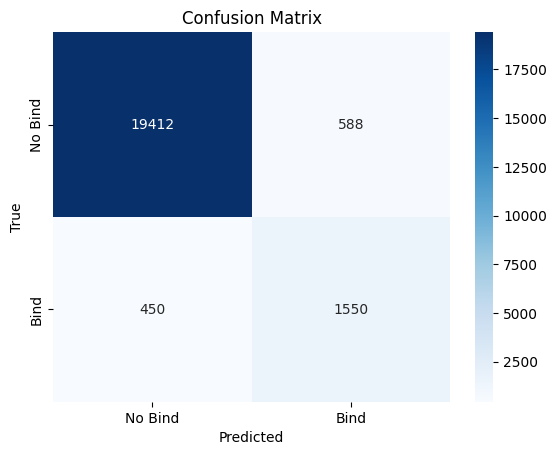

In [75]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

LIGHTGBM

In [91]:
file_name = "lgb_cls.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

In [77]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

In [78]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

y_true = sampled_data['binds']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9544, F1: 0.7505, Precision: 0.7460, Recall: 0.7550


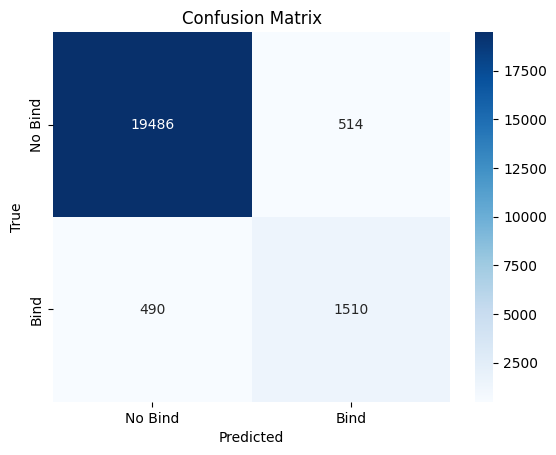

In [79]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [3]:
pd.read_parquet('./sampled_data.parquet').shape

(22000, 7)

In [6]:
sampled_data = pd.read_parquet('./sampled_data.parquet')
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

In [7]:
data

,id,molecule_smiles,protein_name,0,1,2,3,4,5,6,...,693,694,695,696,697,698,699,protein_BRD4,protein_HSA,protein_sEH
0,132343159,CCn1cc2cc(Nc3nc(NCc4nccn4-c4ccccc4)nc(N[C@H]4C...,HSA,0,0,1,0,0,0,0,...,0,4,0,0,0,0,1,0,1,0
1,82817094,CC(=O)SCCNc1nc(NC[C@H]2CC[C@H](C(=O)N[Dy])CC2)...,BRD4,0,1,0,0,0,0,0,...,0,4,0,0,0,0,0,1,0,0
2,288602392,O=C(N[Dy])[C@H]1CC2CCCCC2N1c1nc(Nc2cccc(CN3CCC...,HSA,6,0,1,0,0,0,0,...,0,10,0,0,0,0,2,0,1,0
3,158330658,Cc1cc(F)cc(Nc2nc(NCCCc3nc4c(n3Cc3nccn3C)CCCC4)...,BRD4,2,1,0,1,1,0,0,...,1,4,0,0,0,0,5,1,0,0
4,12372477,Cc1ccc(C#N)cc1Nc1nc(Nc2nc(Cl)c3[nH]cnc3n2)nc(N...,BRD4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21995,66643455,COC(=O)c1ccc(Nc2nc(NCc3cnc4c(c3)c(C)nn4C)nc(N[...,BRD4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,1,0,0
21996,191171069,O=C(N[Dy])c1ccc(Nc2nc(NCc3cnsc3)nc(NCc3cncc(F)...,sEH,0,0,0,0,0,1,0,...,0,0,0,0,0,0,2,0,0,1
21997,148089350,COC(=O)c1scc(C)c1Nc1nc(Nc2cn[nH]c2)nc(Nc2c(Cl)...,sEH,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
21998,178238809,CC(CNc1nc(NCc2cnc3n2CCOC3)nc(Nc2cc([N+](=O)[O-...,HSA,0,0,1,0,1,0,0,...,0,3,0,0,0,0,1,0,1,0


In [4]:
pd.read_parquet('./leash-BELKA/test.parquet').shape

(1674896, 6)

In [42]:
test = pd.read_parquet('./leash-BELKA/test.parquet')

In [43]:

batch_size = 10000
n_batches = len(test) // batch_size + (1 if len(test) % batch_size != 0 else 0)

y_pred_prob_list = []

with tqdm(total=n_batches, desc="Processing batches") as pbar:
   
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, len(test))
         
        test_batch = test.iloc[start_idx:end_idx]
        
        print(f"Processing batch {batch_idx + 1}/{n_batches}, rows {start_idx} to {end_idx}")
        
        predictor = Predictor(test_batch)
        _, y_pred_prob, _, _ = predictor.predict()
        
        y_pred_prob_list.append(y_pred_prob[:, 1])
        
        pbar.update(1)
        
        print(f"Batch {batch_idx + 1} completed.")

y_pred_all = np.concatenate(y_pred_prob_list, axis=0)

Processing batches:   0%|          | 0/168 [00:00<?, ?it/s]

Processing batch 1/168, rows 0 to 10000


Processing batches:   1%|          | 1/168 [00:11<30:41, 11.03s/it]

Batch 1 completed.
Processing batch 2/168, rows 10000 to 20000


Processing batches:   1%|          | 2/168 [00:21<29:25, 10.64s/it]

...

Batch 166 completed.
Processing batch 167/168, rows 1660000 to 1670000


Processing batches:  99%|█████████▉| 167/168 [27:52<00:09,  9.55s/it]

Batch 167 completed.
Processing batch 168/168, rows 1670000 to 1674896


Processing batches: 100%|██████████| 168/168 [27:57<00:00,  9.98s/it]

Batch 168 completed.


In [49]:
test['binds'] = np.round(y_pred_all,1)

In [51]:
test[['id', 'binds']].to_csv('submission.csv', index=False)

In [28]:
del sampled_data

10 to 1 ratio

In [13]:
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(10000000)

binds_0_sampled.show()

+---------+---------------------+---------------------+---------------------+--------------------+------------+-----+
|       id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---------+---------------------+---------------------+---------------------+--------------------+------------+-----+
| 77820552| O=C(NC1(C(=O)O)CC...| Cl.Cl.NCC1CCN(C(N...|         N#Cc1cccnc1N|N#Cc1cccnc1Nc1nc(...|        BRD4|    0|
|  5194143| C#CC[C@H](NC(=O)O...| NCc1cn(C(F)F)c2cc...|     Cc1ccc(N)c(CO)c1|C#CC[C@H](Nc1nc(N...|        BRD4|    0|
| 73909271| O=C(NC(CCc1ccccc1...|        Nc1ccc(F)cc1F| Cc1cc([N+](=O)[O-...|Cc1cc([N+](=O)[O-...|         sEH|    0|
|  6195504| C=CCC(CC=C)(NC(=O...|    NCC12CC=CC(C1)OC2|       NCCc1ncc(Br)s1|C=CCC(CC=C)(Nc1nc...|        BRD4|    0|
|181869914| O=C(Nc1ccc(Br)cc1...|        Nc1cnc(Br)cn1|  Cl.NCCN1CCCS1(=O)=O|O=C(N[Dy])c1cc(Br...|         sEH|    0|
|127011827| O=C(N[C@H](Cc1ccc...| Cl.NC[C@H]1CC[C@H...| 

In [14]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw})
    
sampled_data_with_desc = binds_0_sampled.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [15]:
selected_columns = [
    "id",
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    "binds",
    ]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "features")

In [16]:
num_bins = 20

# Create bins based on molecular weight
windowSpec = Window.orderBy("features")
sampled_data = sampled_data_with_features.withColumn(
    "desc_bin", ntile(num_bins).over(windowSpec)
)

In [25]:
# Add row numbers within each bin
bin_window = Window.partitionBy("desc_bin").orderBy(rand())  # Randomize order
sampled_data = sampled_data.withColumn("row_num", row_number().over(bin_window))

# Keep only 100,000 rows per bin
sample_size = 100000
downsampled_data = sampled_data.filter(col("row_num") <= sample_size).drop("row_num")
binds_0_id = downsampled_data.select(col('id')).toPandas()

25/02/14 11:00:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 11:00:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 11:02:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 11:02:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 15:14:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 15:14:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/02/14 1

In [36]:
binds_0_id.to_csv('binds_0_id.csv', index = False)

In [45]:
data_filtered.printSchema()

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)



In [ ]:
# Final datasetdata_filtered = data.filter(data.id.isin(binds_0_id.id.values.tolist()))
data_filtered = data.filter(data.id.isin(binds_0_id.id.values.tolist()))

In [ ]:
data_filtered.write.save("./intermediates/downsampled_0_10_mln", format="parquet", mode='overwrite')

25/02/14 16:15:36 WARN DAGScheduler: Broadcasting large task binary with size 36.5 MiB


In [ ]:
spark.catalog.clearCache()

In [20]:
binds_1 = pd.read_parquet("./intermediates/1_class")
binds_0 = pd.read_parquet("./intermediates/downsampled_0_10_mln")

In [32]:
final_data = pd.concat([binds_0, binds_1], axis=1).sample(frac=1, random_state=42).reset_index(drop=True)
del binds_1
del binds_0
final_data.shape

(3000000, 10)

In [ ]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=700, useBondTypes=True, includeChirality=True, includeRingMembership=True)

def compute_fn(smiles):
        
        smiles = smiles.replace('[Dy]', '[H]')
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(700, dtype=np.int8)
        
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        
        fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)

        bit_info = ao.GetBitInfoMap()
        arr = np.zeros(700, dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
    
        return arr, bit_info


results = final_data['molecule_smiles'].apply(compute_fn)
final_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
protein_dummies = pd.get_dummies(final_data['protein_name'], prefix='protein', dtype = 'int')
final_data.drop(['molecule_smiles', 'buildingblock1_smiles', 'buildingblock2_smiles', 'buildingblock3_smiles'], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(final_data["fp"].to_list(), index=final_data.index)
final_data = pd.concat([final_data.drop(columns=["fp", "protein_name"]), fingerprint_df, protein_dummies], axis=1)

feature_cols = [col for col in final_data.columns if col not in ['id', 'binds']]

X = final_data[feature_cols]
y = final_data['binds']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_cls = LGBMClassifier()
lgb_cls.fit(X_train, y_train)

y_pred = lgb_cls.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

In [ ]:
file_name = "lgb_cls_10_mln.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

In [ ]:
del final_data
del fingerprint_df
del X_train, X_test, y_train, y_test 

In [ ]:
test = pd.read_parquet('./leash-BELKA/test.parquet')

batch_size = 10000
n_batches = len(test) // batch_size + (1 if len(test) % batch_size != 0 else 0)

y_pred_prob_list = []

with tqdm(total=n_batches, desc="Processing batches") as pbar:
   
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, len(test))
         
        test_batch = test.iloc[start_idx:end_idx]
        
        print(f"Processing batch {batch_idx + 1}/{n_batches}, rows {start_idx} to {end_idx}")
        
        predictor = Predictor(test_batch)
        _, y_pred_prob, _, _ = predictor.predict()
        
        y_pred_prob_list.append(y_pred_prob[:, 1])
        
        pbar.update(1)
        
        print(f"Batch {batch_idx + 1} completed.")

y_pred_all = np.concatenate(y_pred_prob_list, axis=0)